In [1]:
# ============================================================
# 0. 환경설정 및 라이브러리 불러오기
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
# 한글 폰트 설정 (Windows 기준, 필요시 폰트명 조정)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
 
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

In [2]:
# ============================================================
# 1. 데이터 불러오기
# ============================================================
df = pd.read_csv("marketing_clean.csv", encoding="utf-8-sig")
 
print(f"shape: {df.shape}")
df.head()

shape: (2036, 32)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Income_missing,Age,AgeGroup,Children,AnyAccepted
0,1519,1972,PhD,Single,38578.0,1,1,2013-06-22,2,38,4,22,3,3,3,3,3,0,3,8,0,0,0,0,0,0,1,0,42,40대,2,0
1,6720,1968,Master,Together,43795.0,0,1,2013-10-16,11,314,11,53,4,3,107,3,7,3,4,7,0,1,0,0,0,0,1,0,46,40대,1,1
2,1726,1970,Graduation,Single,22585.0,0,0,2013-03-18,23,3,9,15,13,2,39,1,1,1,2,9,1,0,0,0,0,0,1,0,44,40대,0,1
3,3645,1972,PhD,Single,27213.0,1,0,2012-08-30,19,19,3,26,10,9,3,3,2,0,4,8,0,0,0,0,0,0,1,0,42,40대,1,0
4,2552,1955,PhD,Single,55521.0,1,2,2013-10-22,11,416,0,26,0,0,4,9,6,3,6,7,0,1,0,0,0,0,1,0,59,50대,3,1


In [3]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# ============================================================
# H1: 캠페인을 한번이라도 참여했다면 Response의 오즈가 유의하게 높은가?
#     (통제변수 없이 AnyAccepted 단독 효과만 확인하는 baseline 모델)
# ============================================================
model_h1 = smf.logit("Response ~ AnyAccepted", data=df).fit()
print(model_h1.summary())
 
odds_ratio_h1 = np.exp(model_h1.params["AnyAccepted"])
ci_h1 = np.exp(model_h1.conf_int().loc["AnyAccepted"])
p_h1 = model_h1.pvalues["AnyAccepted"]
 
print(f"\nH1 오즈비: {odds_ratio_h1:.2f}")
print(f"H1 95% CI: [{ci_h1.iloc[0]:.2f}, {ci_h1.iloc[1]:.2f}]")
print(f"H1 p-value: {p_h1:.2e}")
 
# 판단
if p_h1 < 0.05 and (ci_h1.iloc[0] > 1 or ci_h1.iloc[1] < 1):
    print("\n-> H1 지지: AnyAccepted와 Response 사이 유의한 양의 연관성 확인, H2로 진행")
else:
    print("\n-> H1 기각: 유의한 연관성 확인 안됨")

Optimization terminated successfully.
         Current function value: 0.372337
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               Response   No. Observations:                 2036
Model:                          Logit   Df Residuals:                     2034
Method:                           MLE   Df Model:                            1
Date:                Fri, 21 Aug 2026   Pseudo R-squ.:                  0.1323
Time:                        17:07:13   Log-Likelihood:                -758.08
converged:                       True   LL-Null:                       -873.71
Covariance Type:            nonrobust   LLR p-value:                 3.165e-52
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -2.3692      0.089    -26.614      0.000      -2.544      -2.195
AnyAccepted     2.0205    

In [4]:
# ============================================================
# H2: 참여도 프록시들을 통제한 후에도 AnyAccepted의 효과는
#     완전히 사라지지 않고 일부 유의하게 남는가?
# ============================================================
from statsmodels.stats.outliers_influence import variance_inflation_factor

proxy_cols = ["NumDealsPurchases", "NumWebVisitsMonth", "Recency",
              "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases"]
 
# AnyAccepted와 프록시 변수들의 상관관계 확인 (얼마나 겹치는 정보인지 사전 점검)
print("=== AnyAccepted-프록시 상관관계 ===")
print(df[proxy_cols + ["AnyAccepted"]].corr()["AnyAccepted"].sort_values(ascending=False))
 
# 다중공선성(VIF) 체크
print("\n=== VIF (다중공선성) ===")
X_cols = ["Income", "Age", "Children"] + proxy_cols
X = df[X_cols].assign(const=1)
vif = pd.DataFrame({
    "변수": X_cols,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(len(X_cols))]
})
print(vif.to_string(index=False))

# H2 모델: 인구통계(Income, Age, Children) + 참여도 프록시 6개 통제
formula_h2 = ("Response ~ AnyAccepted + Income + Age + Children "
              "+ NumDealsPurchases + NumWebVisitsMonth + Recency "
              "+ NumWebPurchases + NumCatalogPurchases + NumStorePurchases")
 
model_h2 = smf.logit(formula_h2, data=df).fit()
print(model_h2.summary())
 
odds_ratio_h2 = np.exp(model_h2.params["AnyAccepted"])
ci_h2 = np.exp(model_h2.conf_int().loc["AnyAccepted"])
p_h2 = model_h2.pvalues["AnyAccepted"]
 
print(f"\nH2 오즈비: {odds_ratio_h2:.2f}")
print(f"H2 95% CI: [{ci_h2.iloc[0]:.2f}, {ci_h2.iloc[1]:.2f}]")
print(f"H2 p-value: {p_h2:.2e}")
 
# H1과 비교
model_h1 = smf.logit("Response ~ AnyAccepted", data=df).fit(disp=0)
odds_ratio_h1 = np.exp(model_h1.params["AnyAccepted"])
 
print("\n=== H1 vs H2 비교 ===")
comparison = pd.DataFrame({
    "모델": ["H1 (통제 없음)", "H2 (프록시+인구통계 통제)"],
    "오즈비": [odds_ratio_h1, odds_ratio_h2],
    "p-value": [model_h1.pvalues["AnyAccepted"], p_h2]
})
print(comparison.to_string(index=False))
 
 
# 판단
if p_h2 < 0.05 and (ci_h2.iloc[0] > 1 or ci_h2.iloc[1] < 1):
    print("\n-> H2 지지: 프록시 통제 후에도 AnyAccepted 효과 유의하게 잔존 -> H3로 진행")
else:
    print("\n-> H2 기각: 프록시 통제 후 효과가 성향으로 대부분 설명됨")

=== AnyAccepted-프록시 상관관계 ===
AnyAccepted            1.000000
NumCatalogPurchases    0.307675
NumWebPurchases        0.211509
NumStorePurchases      0.195033
Recency               -0.015452
NumDealsPurchases     -0.090764
NumWebVisitsMonth     -0.119964
Name: AnyAccepted, dtype: float64

=== VIF (다중공선성) ===
                 변수      VIF
             Income 3.184228
                Age 1.086995
           Children 1.756804
  NumDealsPurchases 1.607279
  NumWebVisitsMonth 2.269744
            Recency 1.002991
    NumWebPurchases 1.665709
NumCatalogPurchases 2.298000
  NumStorePurchases 1.948109
Optimization terminated successfully.
         Current function value: 0.321007
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:               Response   No. Observations:                 2036
Model:                          Logit   Df Residuals:                     2025
Method:                           MLE   Df Model:              

=== 인코딩 확인 ===
     Education  Education_ord
31       Basic              0
2   Graduation              1
1       Master              2
0          PhD              3
K=2 | Inertia=6890 | Silhouette=0.300
K=3 | Inertia=5720 | Silhouette=0.255
K=4 | Inertia=4979 | Silhouette=0.245
K=5 | Inertia=4418 | Silhouette=0.234
K=6 | Inertia=3968 | Silhouette=0.250
K=7 | Inertia=3666 | Silhouette=0.247
K=8 | Inertia=3364 | Silhouette=0.252

K 결정 그래프 저장: cluster_k_selection.png

클러스터별 표본 수:
Cluster
0    525
1    839
2    672
Name: count, dtype: int64
PCA 시각화 저장: cluster_5var_edu_pca.png
PCA 누적 설명분산: [0.42793187 0.66736988]

=== 클러스터별 프로파일 ===
Cluster               0         1         2
Income         48249.51  36238.39  74725.99
Age               49.25     41.21     46.79
Children           1.38      1.15      0.37
Education_ord      2.62      1.13      1.59
Mnt_Total        364.21    190.59   1312.97

=== 클러스터별 Education 원본 분포(%) ===
Education  Basic  Graduation  Master   PhD
Cluster               

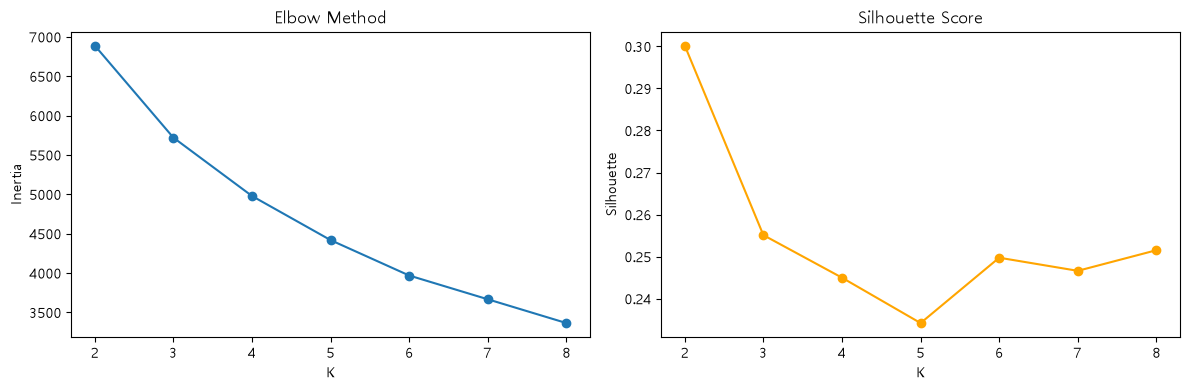

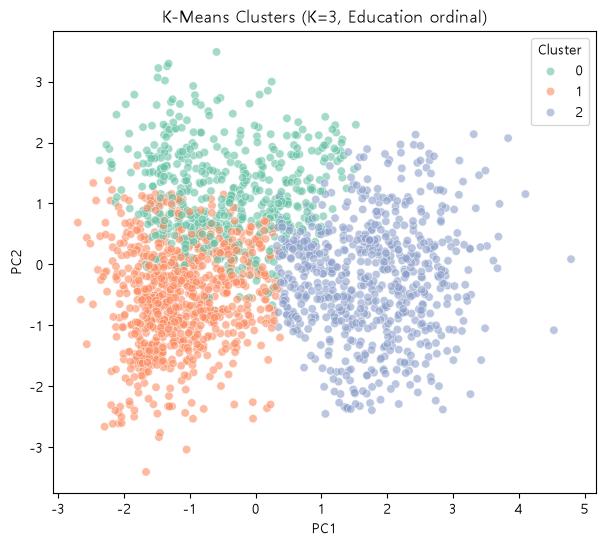

In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf


# ============================================================
# 1. 변수 준비
#    - Mnt_Total: 소비 카테고리 6개 합산
#    - Education: 학력 순서가 명확히 존재 -> 순서형 인코딩 (0~3)
# ============================================================
mnt_cols = ["MntWines", "MntFruits", "MntMeatProducts",
            "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
df["Mnt_Total"] = df[mnt_cols].sum(axis=1)

education_order = {"Basic": 0, "Graduation": 1, "Master": 2, "PhD": 3}
df["Education_ord"] = df["Education"].map(education_order)

cluster_cols = ["Income", "Age", "Children", "Education_ord", "Mnt_Total"]

print("=== 인코딩 확인 ===")
print(df[["Education", "Education_ord"]].drop_duplicates().sort_values("Education_ord"))

# ============================================================
# 2. 표준화
# ============================================================
X = df[cluster_cols].copy()
X_scaled = StandardScaler().fit_transform(X)

# ============================================================
# 3. 적정 K 탐색
# ============================================================
inertias, silhouettes = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    print(f"K={k} | Inertia={km.inertia_:.0f} | Silhouette={silhouettes[-1]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_range), inertias, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("K"); axes[0].set_ylabel("Inertia")
axes[1].plot(list(K_range), silhouettes, marker="o", color="orange")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("K"); axes[1].set_ylabel("Silhouette")
plt.tight_layout()
plt.savefig("cluster_k_selection.png", dpi=100)
print("\nK 결정 그래프 저장: cluster_k_selection.png")

# ============================================================
# 4. 최종 클러스터링 (K=3)
# ============================================================
K_FINAL = 3
km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
df["Cluster"] = km_final.fit_predict(X_scaled)

print(f"\n클러스터별 표본 수:")
print(df["Cluster"].value_counts().sort_index())

# ============================================================
# 5. PCA 시각화
# ============================================================
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)
df["PC1"], df["PC2"] = pca_result[:, 0], pca_result[:, 1]

plt.figure(figsize=(7, 6))
sns.scatterplot(data=df, x="PC1", y="PC2", hue="Cluster", palette="Set2", alpha=0.6)
plt.title(f"K-Means Clusters (K={K_FINAL}, Education ordinal)")
plt.savefig("cluster_pca.png", dpi=100)
print("PCA 시각화 저장: cluster_5var_edu_pca.png")
print(f"PCA 누적 설명분산: {pca.explained_variance_ratio_.cumsum()}")

# ============================================================
# 6. 클러스터 프로파일링
# ============================================================
print("\n=== 클러스터별 프로파일 ===")
print(df.groupby("Cluster")[cluster_cols].mean().round(2).T)

print("\n=== 클러스터별 Education 원본 분포(%) ===")
print((pd.crosstab(df["Cluster"], df["Education"], normalize="index") * 100).round(1))

print("\n=== (참고) 클러스터별 Marital_Status 분포(%) ===")
print((pd.crosstab(df["Cluster"], df["Marital_Status"], normalize="index") * 100).round(1))

print("\n=== 클러스터별 Response율 / AnyAccepted율 ===")
print(df.groupby("Cluster")[["Response", "AnyAccepted"]].mean().round(3))

# ============================================================
# 7. H3: AnyAccepted x Cluster 교호작용
# ============================================================
model_h3 = smf.logit(
    "Response ~ AnyAccepted * C(Cluster) + C(Marital_Status) "
    "+ NumDealsPurchases + NumWebVisitsMonth + Recency "
    "+ NumWebPurchases + NumCatalogPurchases + NumStorePurchases",
    data=df
).fit()
print("\n" + "="*70)
print(model_h3.summary())

# ============================================================
# 8. 클러스터별 효과크기(uplift)
# ============================================================
segment_uplift = df.groupby("Cluster").apply(
    lambda g: g.loc[g["AnyAccepted"] == 1, "Response"].mean()
            - g.loc[g["AnyAccepted"] == 0, "Response"].mean()
).sort_values(ascending=False)

print("\n클러스터별 AnyAccepted 효과크기 (Response율 차이, %p):")
print((segment_uplift * 100).round(2))
